In [43]:
import seaborn as sns
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import(r2_score, mean_squared_error, accuracy_score, confusion_matrix,
classification_report, f1_score, roc_auc_score, average_precision_score)

from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from xgboost import XGBRegressor, XGBClassifier

import warnings
warnings.filterwarnings("ignore")

<br></br>

In [44]:
# Fetch file id on Drive
file_id = "1fNiz9QRSD5drWAs3k1Ji09D_u3COOJWR"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
gdown.download(url, "bank_transactions.csv", quiet=True)

# Load url
bank_df = pd.read_csv("bank_transactions.csv")

# Show first 5 rows
bank_df.head(5)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


<br></br>

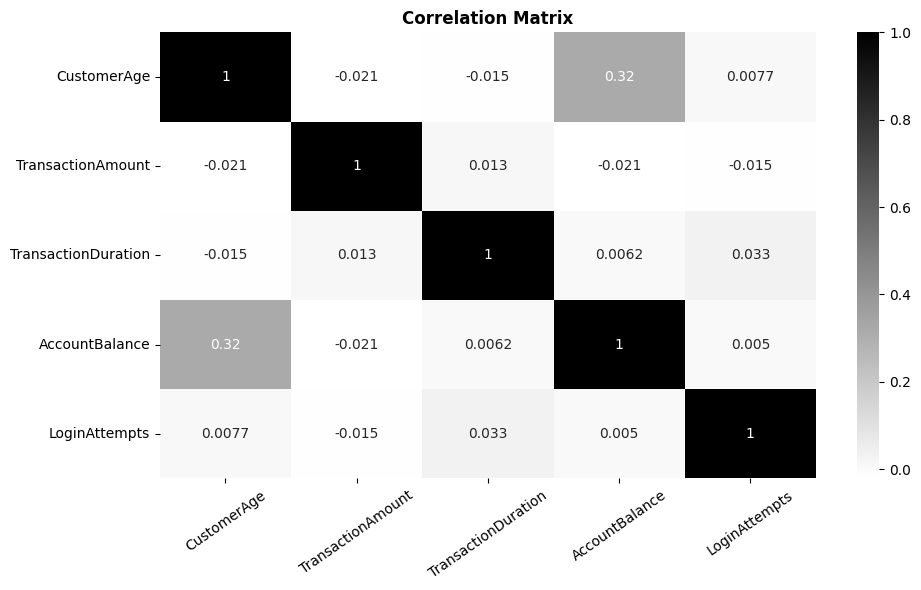

In [51]:
# Correlation matrix
cm = bank_df[["CustomerAge","TransactionAmount","TransactionDuration","AccountBalance", "LoginAttempts"]].corr()

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, cmap="binary")
plt.title("Correlation Matrix", fontweight="bold")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

<br></br>

# **Which Factors Most Influence Account Balance?**

### Linear Regression

In [46]:
# Set up target and predictors
X = bank_df[["CustomerAge","TransactionAmount","TransactionDuration", "LoginAttempts", "Location", "Channel", "CustomerOccupation", "TransactionType"]]
y = bank_df['AccountBalance']

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Train Test set up
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Get numeric column to normalize
num_cols = ["CustomerAge","TransactionAmount","TransactionDuration", "LoginAttempts"]

# Initialize scaler
scaler = StandardScaler()

# Normalize numeric columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])

# Fit regression object
lr = LinearRegression()
lr.fit(X_train, y_train)

# Evaluate linear regression
y_pred = lr.predict(X_test)

print("Linear regression results:")
print("***************************************************")
print("R squarred:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Linear regression results:
***************************************************
R squarred: 0.49007430832199217
RMSE: 2783.2482503030556


<br></br>

# XGBoost

In [47]:
# XGBoost model
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8,
                   colsample_bytree=0.8, random_state=42)

# Train Test set up
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Fit xgb
xgb.fit(X_train, y_train)

# Predict
xgb_predict = xgb.predict(X_test)

# Evaluate
print("XGBoost results:")
print("***************************************************")
print("R squarred:", r2_score(y_test, xgb_predict))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_predict)))

XGBoost results:
***************************************************
R squarred: 0.9020917998131006
RMSE: 1219.5736471978273


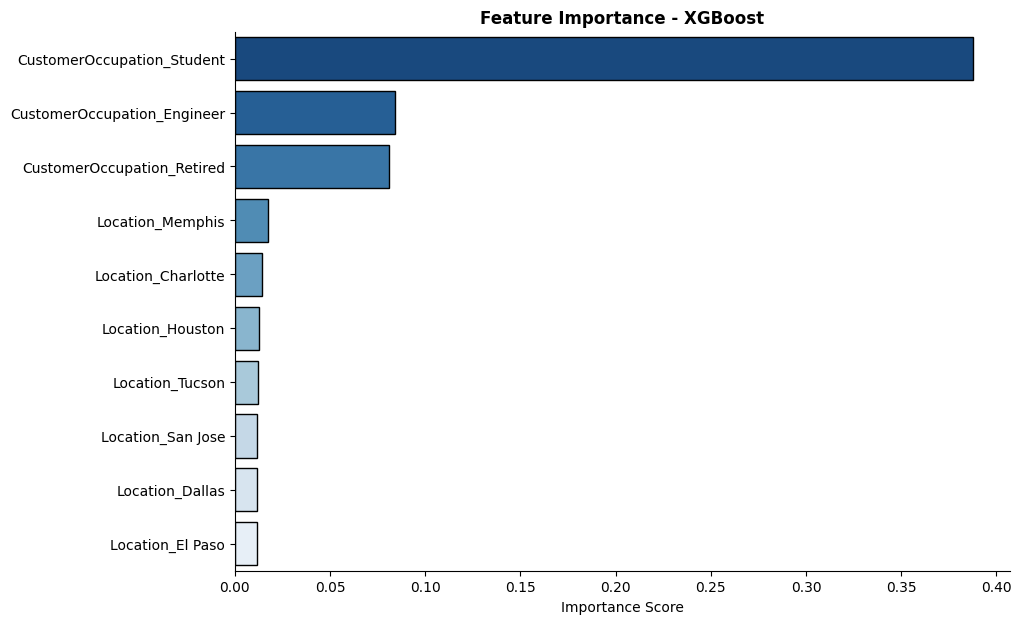

In [48]:
# Create dataframe for importance features
feature_importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

# Sort by importance
feature_importance_xgb = feature_importance_xgb.sort_values("Importance", ascending=False).head(10)

# Barplot
plt.figure(figsize=(10,7))
sns.barplot(feature_importance_xgb, x="Importance", y="Feature", palette="Blues_r", edgecolor= "black")
plt.title("Feature Importance - XGBoost", fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

<br></br>

# Random Forest

In [49]:
# Random forest model
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs= -1)

# Train Test set up
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train model
rf.fit(X_train, y_train)

# Predict
rf_predict = rf.predict(X_test)

# Evaluate
print("Random Forest results:")
print("***************************************************")
print("R squarred:", r2_score(y_test, rf_predict))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_predict)))


Random Forest results:
***************************************************
R squarred: 0.998911864387505
RMSE: 128.5701083661106


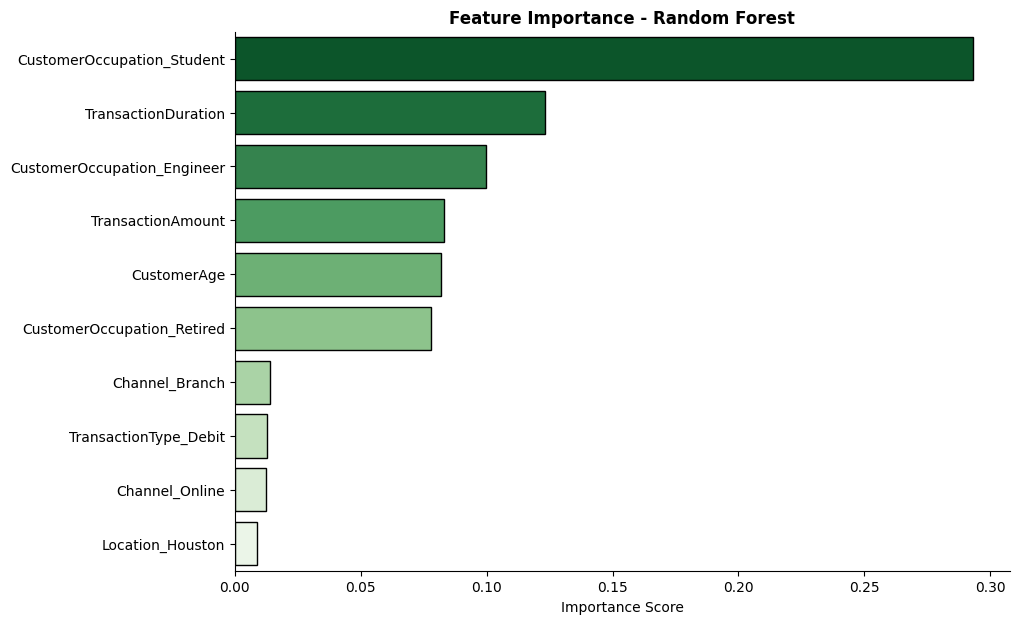

In [52]:
# Create dataframe for importance features
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values("Importance", ascending=False).head(10)

# Barplot
plt.figure(figsize=(10,7))
sns.barplot(feature_importance, x="Importance", y="Feature", palette="Greens_r", edgecolor= "black")
plt.ylabel("")
plt.xlabel("Importance Score")
plt.title("Feature Importance - Random Forest", fontweight="bold")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()